In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

from GRF import generate_gaussian_random_field

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB = derive_density_maps()

[17:24:20] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=690882;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=681525;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## **Global Fractal Dimension**

In [2]:
# Orion A
region_name = "Orion A"

# range Orion A (whole)
threshold_min = 1.95e21
threshold_max = 7.5e22

# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

region_name = "Orion B"

# range Orion B
threshold_min = 2.5e21
threshold_max = 7.5e22

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

2.971222110192121
2.860226447812054


In [2]:
N_H2, N_H2_OA, N_H2_OB, wcs, wcs_OA, wcs_OB = derive_density_maps(remove_regions=False)

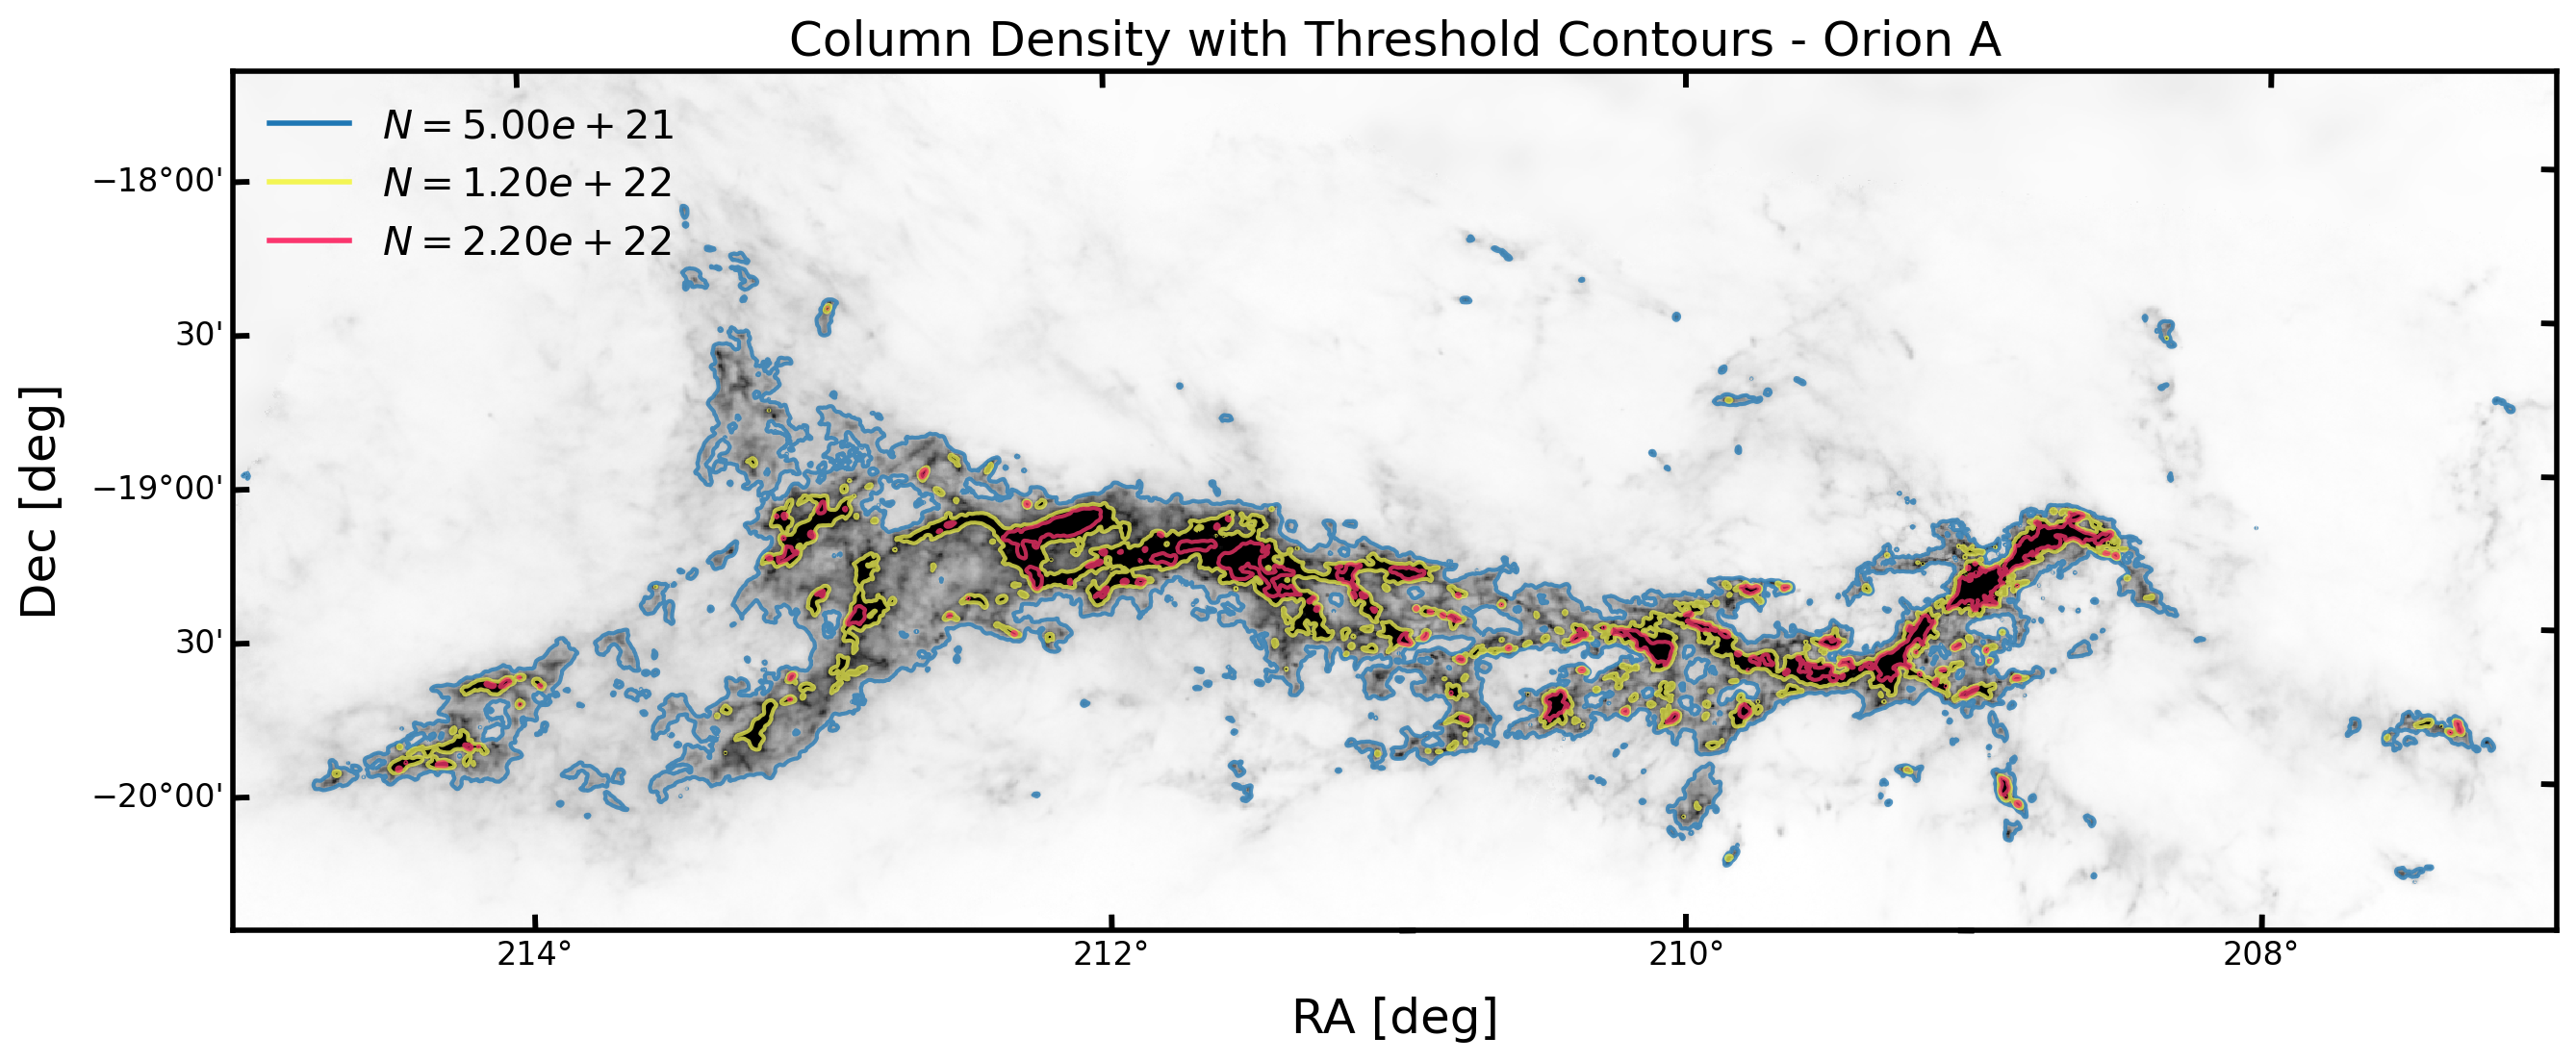

In [9]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

thresholds = [5e21, 1.2e22, 2.2e22]  # low, transition, high
colors = ['#1f77b4', '#f3f554', '#fb366e']  # blue, orange, red

fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection=wcs_OA)

# show the base map
im = ax.imshow(N_H2_OA, origin='lower', cmap='Grays',
               vmin=np.nanpercentile(N_H2_OA, 5),
               vmax=np.nanpercentile(N_H2_OA, 99))
ax.set_title('Column Density with Threshold Contours - Orion A', fontsize = 18)
ax.coords[0].set_axislabel('RA [deg]', fontsize = 18)
ax.coords[1].set_axislabel('Dec [deg]', fontsize = 18)

# draw the contours and keep handles for legend
handles = []
for thr, col in zip(thresholds, colors):
    cs = ax.contour(N_H2_OA, levels=[thr], colors=[col],
                    linewidths=1.5, alpha=0.75)
    # create a proxy line for legend
    line = mlines.Line2D([], [], color=col, linewidth=2,
                         label=f"$N = {thr:.2e}$")
    handles.append(line)

# add a custom legend (top left)
legend = ax.legend(handles=handles, loc='upper left', fontsize=15)
# make legend text black
for text in legend.get_texts():
    text.set_color("black")

# add colorbar
# cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label(r'$N_{\mathrm{H_2}}$ [cm$^{-2}$]')

# plt.savefig("figures/gallery_thresholds_OA.png", dpi=300)

lat_center = -19 * u.deg  # adjust if your map is centered elsewhere
lon_min = 207 * u.deg
lon_max = 215.0 * u.deg

# Convert world coordinates to pixel coordinates
x_min_pix, _ = wcs_OA.world_to_pixel(SkyCoord(lon_min, lat_center, frame='galactic'))
x_max_pix, _ = wcs_OA.world_to_pixel(SkyCoord(lon_max, lat_center, frame='galactic'))
ax.set_xlim(x_max_pix, x_min_pix) 

lat_min = -20.5 * u.deg
lat_max = -17.7 * u.deg

lon_center = 211 * u.deg  # pick roughly the middle of your longitude range

_, y_min_pix = wcs_OA.world_to_pixel(SkyCoord(lon_center, lat_min, frame='galactic'))
_, y_max_pix = wcs_OA.world_to_pixel(SkyCoord(lon_center, lat_max, frame='galactic'))

ax.set_ylim(y_min_pix, y_max_pix) 

plt.tight_layout()
plt.show()

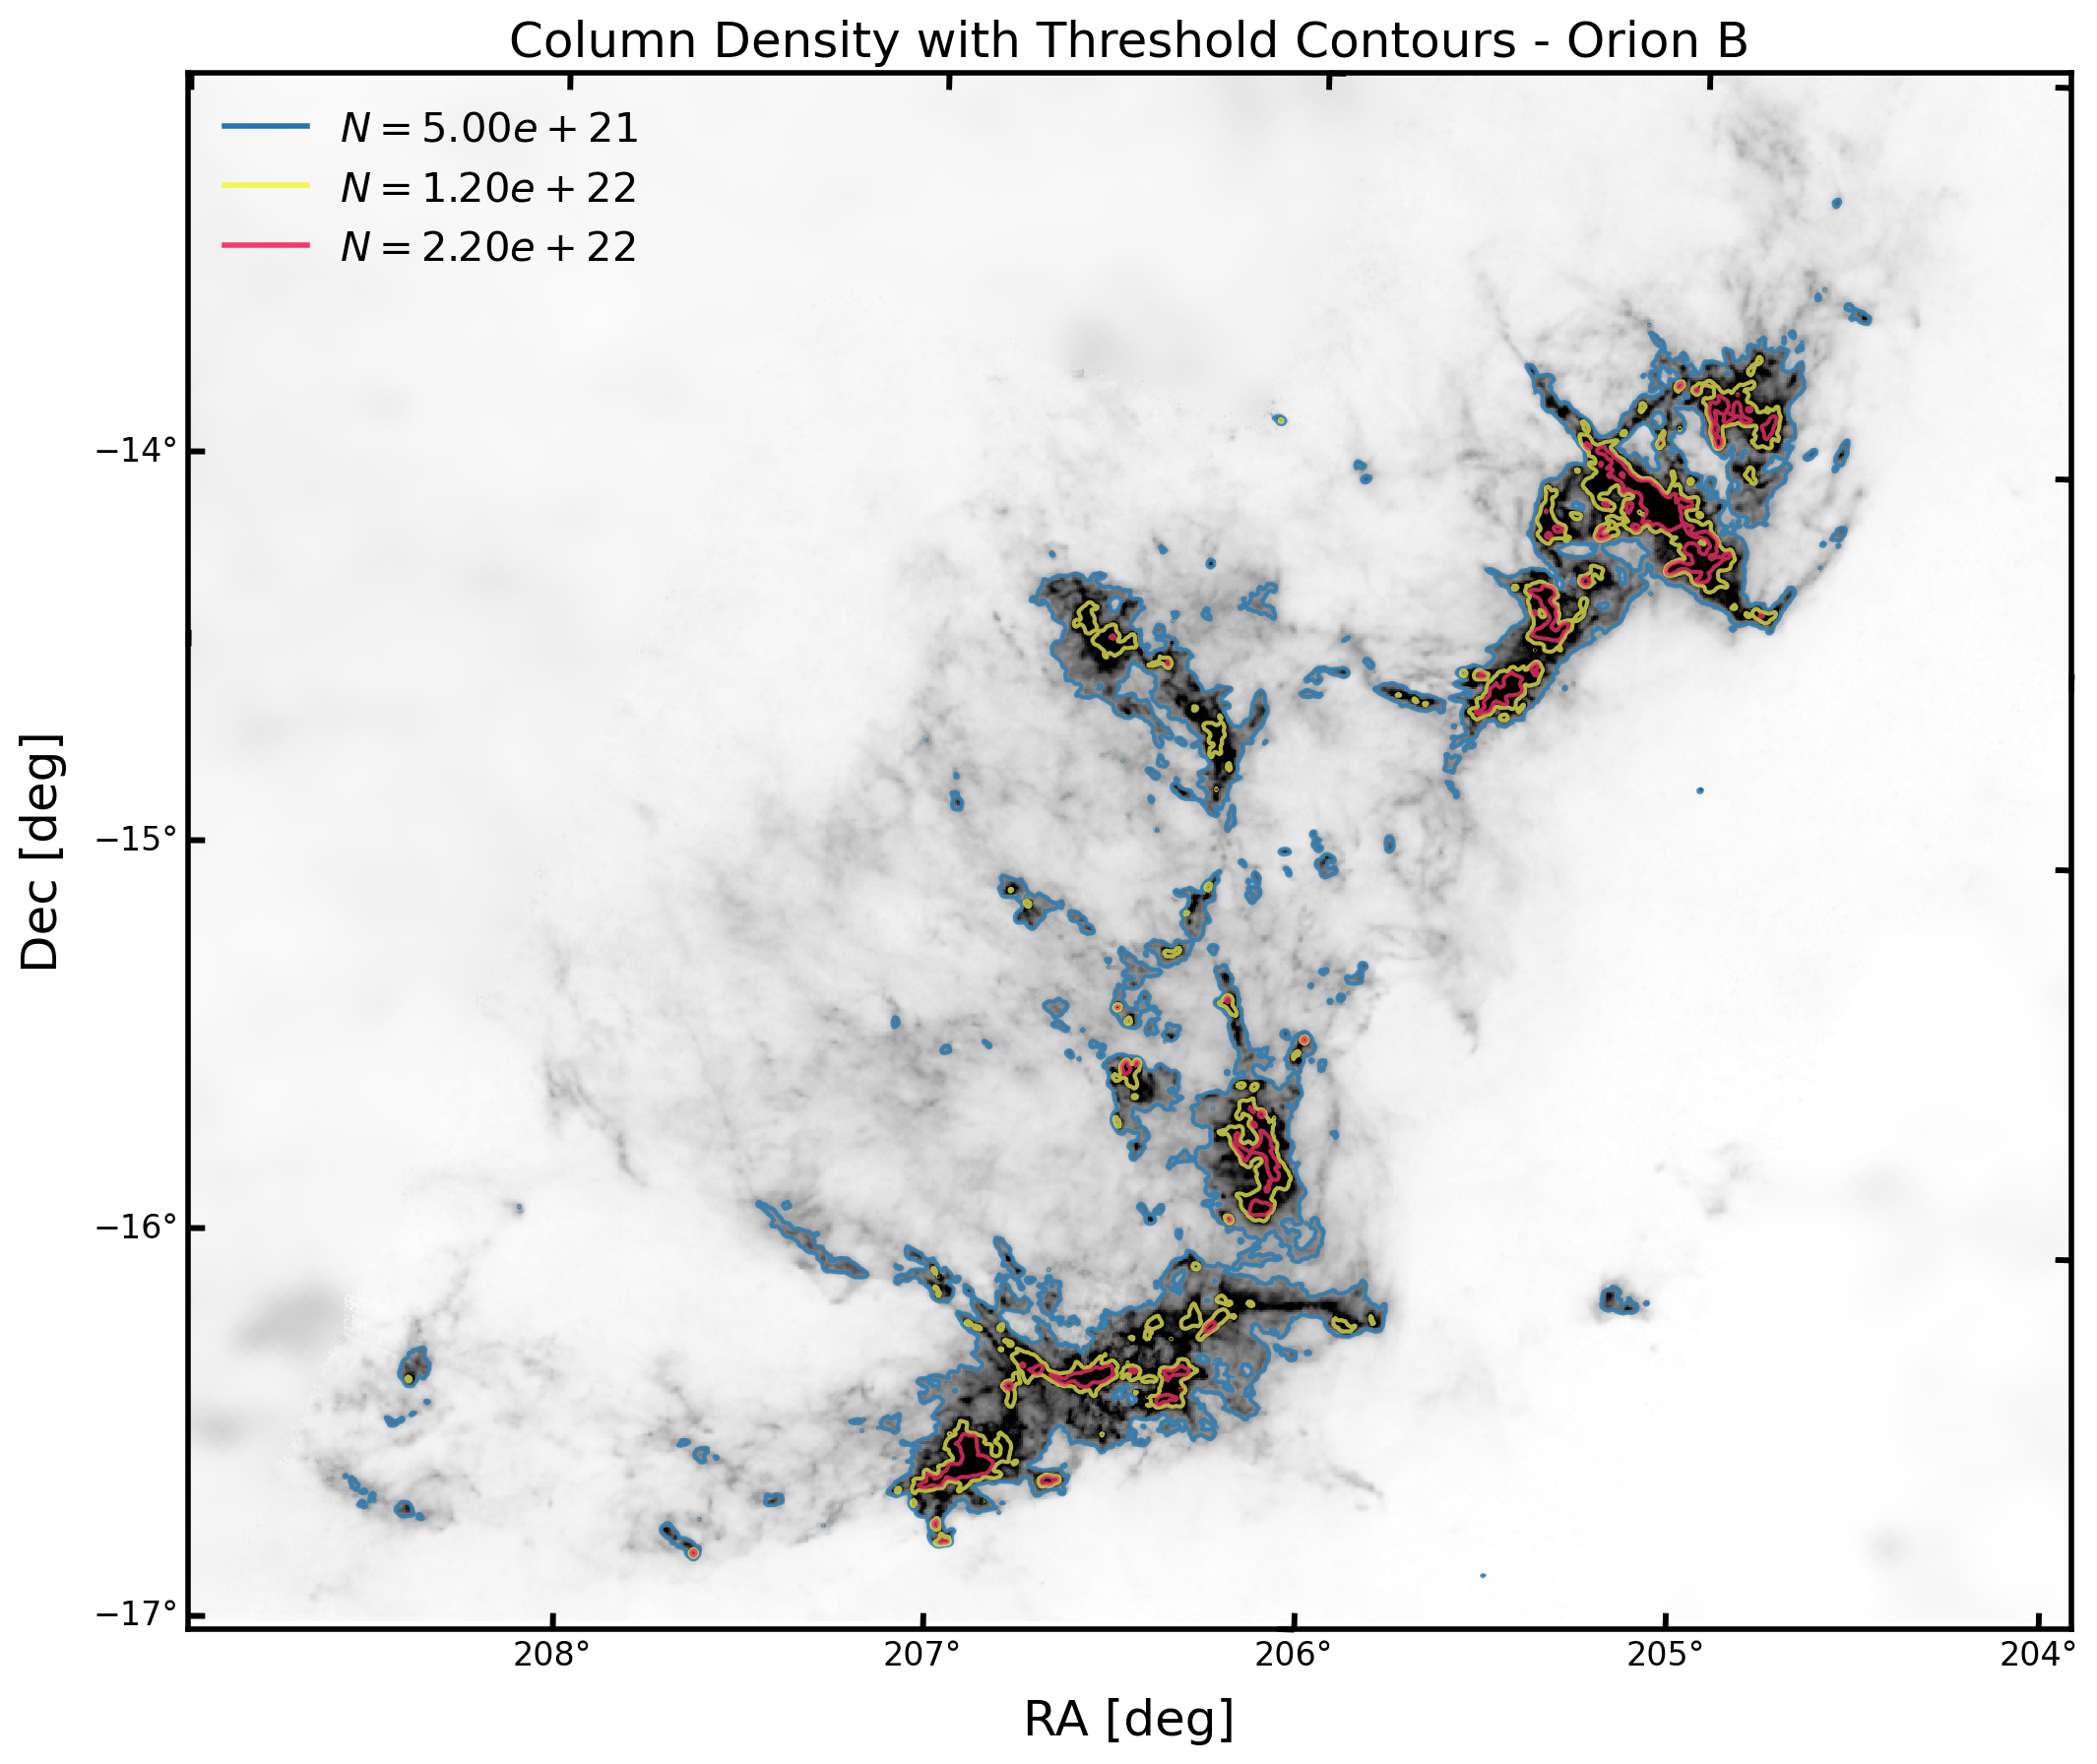

In [10]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

thresholds = [5e21, 1.2e22, 2.2e22]  # low, transition, high
colors = ['#1f77b4', '#f3f554', '#fb366e']  # blue, orange, red

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection=wcs_OB)

# show the base map
im = ax.imshow(N_H2_OB, origin='lower', cmap='Grays',
               vmin=np.nanpercentile(N_H2_OB, 5),
               vmax=np.nanpercentile(N_H2_OB, 99))
ax.set_title('Column Density with Threshold Contours - Orion B', fontsize = 18)
ax.coords[0].set_axislabel('RA [deg]', fontsize = 18)
ax.coords[1].set_axislabel('Dec [deg]', fontsize = 18)

# draw the contours and keep handles for legend
handles = []
for thr, col in zip(thresholds, colors):
    cs = ax.contour(N_H2_OB, levels=[thr], colors=[col],
                    linewidths=1.5, alpha=0.75)
    # create a proxy line for legend
    line = mlines.Line2D([], [], color=col, linewidth=2,
                         label=f"$N = {thr:.2e}$")
    handles.append(line)

# add a custom legend (top left)
legend = ax.legend(handles=handles, loc='upper left', fontsize=15)
# make legend text black
for text in legend.get_texts():
    text.set_color("black")

# add colorbar
# cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label(r'$N_{\mathrm{H_2}}$ [cm$^{-2}$]')

# plt.savefig("figures/gallery_thresholds_OA.png", dpi=300)

lat_min = -17 * u.deg
lat_max = -13 * u.deg

lon_center = 206 * u.deg  # pick roughly the middle of your longitude range

_, y_min_pix = wcs_OB.world_to_pixel(SkyCoord(lon_center, lat_min, frame='galactic'))
_, y_max_pix = wcs_OB.world_to_pixel(SkyCoord(lon_center, lat_max, frame='galactic'))

ax.set_ylim(y_min_pix, y_max_pix) 

# Desired longitude limits (with some representative latitude, e.g. center of your map)
lat_center = -14.5 * u.deg  # adjust if your map is centered elsewhere
lon_min = 204 * u.deg
lon_max = 209 * u.deg

# Convert world coordinates to pixel coordinates
x_min_pix, _ = wcs_OB.world_to_pixel(SkyCoord(lon_min, lat_center, frame='galactic'))
x_max_pix, _ = wcs_OB.world_to_pixel(SkyCoord(lon_max, lat_center, frame='galactic'))

ax.set_xlim(x_max_pix, x_min_pix) 

plt.tight_layout()
plt.show()

## **Local Fractal Dimension**

## **MSD**